# N8 · Competitor Opens Next to 50 Top Branches — the response game

**Panel question** — asked by the **CRO** with the **Head of Product**
watching for network realism: *"A competitor opens next to 50 of our top
branches. What's your response framework?"*

The framework, priced: **diagnose before you shoot** (structural entrant or
12-week promo?), **non-price levers first**, **targeted beats blanket**
(using the case-study engine's own break-even rule), and **measure with
matched controls**, because you can't randomise a competitor.

The war story that anchors it: Delta's "Meet or Beat" — matching hands your
pricing strategy to your competitor. Never blanket-match first.

In [1]:
# %matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from _style import C, apply_style
apply_style()
rng = np.random.default_rng(31)

from distribution_economics import margin_support_breakeven

# --- The 50 affected branches: heterogeneous, like real ones -----------------
N_AFF = 50
br = pd.DataFrame({
    "weekly_load": rng.lognormal(np.log(60_000), 0.5, N_AFF),   # £ FX sold/week
    "margin_bps": rng.normal(430, 35, N_AFF),                   # pocket spread
    "local_elasticity": -np.clip(rng.normal(1.0, 0.35, N_AFF), 0.4, 2.2),
})
br["weekly_contrib"] = br.weekly_load * br.margin_bps / 1e4 * 0.55  # after costs
HIT = 0.08                    # competitor entry takes 8% of volume if we do nothing
print(f"{N_AFF} affected branches | £{br.weekly_contrib.sum():,.0f}/week "
      f"contribution at risk of an {HIT:.0%} volume hit")

50 affected branches | £74,239/week contribution at risk of an 8% volume hit


## 1. Diagnose first: structural or promotional?

The first question on ANY competitor move. A fintech kiosk with venture
money runs a 12-week land-grab; another cash bureau with the same cost
structure is there to stay. The optimal response differs completely — so
price the strategies under BOTH scenarios before choosing.

In [2]:
CUT_BPS = 60                  # candidate price response: margin cut
NONPRICE_COST = 60            # £/week/branch: availability push, buyback promo
NONPRICE_RECOVERY = 0.45      # share of the volume hit it wins back
MATCH_RECOVERY = 0.55         # share of the hit a price response wins back
RAMP, HIT_MAX = 0.004, 0.20   # unopposed STRUCTURAL entrant keeps taking share

def hit_path(scenario, responded):
    """Weekly volume-hit path. A promo reverts after 12 weeks; a structural
    entrant unopposed RAMPS from 8% toward 20%; any response pins it at 8%."""
    if scenario == "promo":
        T = 52
        h = np.where(np.arange(T) < 12, HIT, 0.0)
    else:
        T = 52
        h = np.minimum(HIT + RAMP * np.arange(T), HIT_MAX)
        if responded:
            h = np.full(T, HIT)
    return h

def total_value(strategy, scenario):
    """Portfolio contribution delta vs pre-entry (£), over 52 weeks."""
    h = hit_path(scenario, responded=(strategy != "do_nothing"))
    total = 0.0
    for _, row in br.iterrows():
        base = row.weekly_contrib
        cut_frac = CUT_BPS / row.margin_bps
        be = margin_support_breakeven(row.local_elasticity, cut_frac)
        price_here = (strategy == "blanket_cut" or
                      (strategy == "targeted_cut" and be["accretive"]))
        for ht in h:
            if strategy == "do_nothing":
                total += -base * ht
            elif price_here:
                uplift = 0.7 * abs(row.local_elasticity) * cut_frac  # damped
                vol = 1 - ht + MATCH_RECOVERY * ht + uplift
                total += base * (1 - cut_frac) * vol - base
            else:                       # non-price bundle (also the fallback
                total += -base * ht * (1 - NONPRICE_RECOVERY) - NONPRICE_COST
    return total

scenarios = ["promo", "structural"]
strategies = ["do_nothing", "non_price", "targeted_cut", "blanket_cut"]
payoff = pd.DataFrame({sc: [total_value(st, sc) / 1e3 for st in strategies]
                       for sc in scenarios}, index=strategies)
payoff.columns = ["12-week promo", "structural entrant"]
print("Payoff matrix (£k contribution vs pre-entry, 52-week horizon):")
print(payoff.round(0).to_string())
best = payoff.idxmax()
print(f"\nBest response if promo:      {best['12-week promo']}")
print(f"Best response if structural: {best['structural entrant']}")
print("\nThe diagnosis IS the decision: hold through a promo (let their "
      "funding run out); defend a structural entrant — but TARGETED, never "
      "blanket. Matching everywhere is the Delta 'Meet or Beat' error: it "
      "burns margin in branches that never needed defending.")

Payoff matrix (£k contribution vs pre-entry, 52-week horizon):
              12-week promo  structural entrant
do_nothing            -71.0              -634.0
non_price            -195.0              -326.0
targeted_cut         -177.0              -286.0
blanket_cut          -230.0              -322.0

Best response if promo:      do_nothing
Best response if structural: targeted_cut

The diagnosis IS the decision: hold through a promo (let their funding run out); defend a structural entrant — but TARGETED, never blanket. Matching everywhere is the Delta 'Meet or Beat' error: it burns margin in branches that never needed defending.


## 2. Which branches get the targeted response?

The engine's `margin_support_breakeven` rule, branch by branch: a margin cut
is self-funding only where local elasticity delivers more volume than the
giveaway costs. Segment the 50; defend where defence pays.

Defend with price: 26 of 50 branches (elastic locals). The other 24 get the non-price bundle (availability, buyback promo, click-&-collect push) — cheaper than margin they'd never earn back.


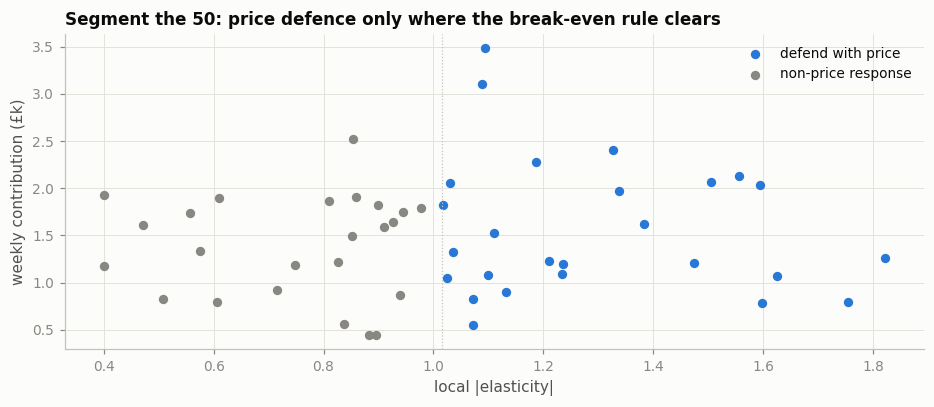

In [3]:
br["breakeven_volume_uplift"] = [margin_support_breakeven(e, CUT_BPS / m)["breakeven_volume_uplift"]
                          for e, m in zip(br.local_elasticity, br.margin_bps)]
br["implied_volume_uplift"] = [margin_support_breakeven(e, CUT_BPS / m)["implied_volume_uplift"]
                        for e, m in zip(br.local_elasticity, br.margin_bps)]
br["defend"] = br.implied_volume_uplift > br.breakeven_volume_uplift
print(f"Defend with price: {br.defend.sum()} of {N_AFF} branches "
      f"(elastic locals). The other {(~br.defend).sum()} get the non-price "
      "bundle (availability, buyback promo, click-&-collect push) — cheaper "
      "than margin they'd never earn back.")

fig, ax = plt.subplots(figsize=(8.6, 3.8))
for flag, lab, col in [(True, "defend with price", C["blue"]),
                       (False, "non-price response", C["muted"])]:
    sub = br[br.defend == flag]
    ax.scatter(-sub.local_elasticity, sub.weekly_contrib / 1e3, s=26,
               color=col, label=lab)
ax.axvline(-br[br.defend].local_elasticity.max() - 0.001, color=C["axis"],
           lw=0.8, ls=":")
ax.set_xlabel("local |elasticity|"); ax.set_ylabel("weekly contribution (£k)")
ax.set_title("Segment the 50: price defence only where the break-even rule clears")
ax.legend()
plt.tight_layout(); plt.show()

## 3. Measure it with matched controls — you can't randomise a competitor

Simulate 20 weeks of network data (entry at week 9) plus a seasonal uptrend.
The naive before/after read is polluted by the trend; matching each affected
branch to its nearest unaffected twin (pre-period volume) recovers the true
−8%.

In [4]:
N_ALL, T_W, EVENT = 400, 20, 8
size_all = rng.lognormal(np.log(60_000), 0.5, N_ALL)
aff_idx = rng.choice(N_ALL, N_AFF, replace=False)
is_aff = np.zeros(N_ALL, bool); is_aff[aff_idx] = True
trend = 1 + 0.004 * np.arange(T_W)                     # market drifts UP

vol = np.empty((N_ALL, T_W))
for t in range(T_W):
    hit = is_aff & (t >= EVENT)
    vol[:, t] = size_all * trend[t] * (1 - HIT * hit) * rng.lognormal(0, 0.03, N_ALL)

aff_change = vol[is_aff, EVENT:].mean() / vol[is_aff, :EVENT].mean() - 1
naive = aff_change                                     # before/after, no control
# matched controls: nearest unaffected branch by pre-period mean volume
pre = vol[:, :EVENT].mean(axis=1)
ctrl_pool = np.where(~is_aff)[0]
matches = ctrl_pool[np.abs(pre[ctrl_pool][None, :]
                           - pre[aff_idx][:, None]).argmin(axis=1)]
ctrl_change = vol[matches, EVENT:].mean() / vol[matches, :EVENT].mean() - 1
did = aff_change - ctrl_change

print(f"Naive before/after on affected branches: {naive:+.1%}  "
      "(trend hides half the hit)")
print(f"Matched-control DiD                     : {did:+.1%}  (truth −8.0%)")
print("Matching on pre-period volume finds each branch's twin; the trend "
      "cancels out. Same logic as N1's synthetic control, cheaper.")

Naive before/after on affected branches: -4.5%  (trend hides half the hit)
Matched-control DiD                     : -8.6%  (truth −8.0%)
Matching on pre-period volume finds each branch's twin; the trend cancels out. Same logic as N1's synthetic control, cheaper.


## The 60-second answer

> "Before I touch price I'd ask one question: is this structural or a
> twelve-week land-grab? I priced both worlds. A blanket sixty-basis-point
> match is dominated in *both* — margin cost across fifty branches outweighs
> the volume it wins back, which is the Delta 'Meet or Beat' lesson: match
> everyone and you've handed your pricing strategy to the competitor.
>
> What wins is a split response. First, non-price levers everywhere —
> availability, buyback promotion, pushing click-and-collect — because in a
> convenience business those defend share without repricing anything. Then
> price defence only in the branches where the break-even rule clears: with
> local elasticity and margin headroom, roughly half of the fifty justify a
> targeted cut; the rest would never earn the giveaway back. And I'd
> measure the whole episode with matched controls — each affected branch
> paired to its nearest unaffected twin — because a naive before-and-after
> read was hiding half the impact behind the market trend.
>
> If it's a promo, we mostly hold and let their funding run out. If it's
> structural, the targeted defence becomes permanent and I'd fold it into
> the AOP with the competitor-sensitivity line the scenario engine already
> produces."

### What I'd say if pushed deeper

1. **"How do you tell structural from promotional?"** — Their cost
   structure and behaviour: a venture-funded kiosk pricing below its own
   cost-to-serve is buying share it can't keep; a bureau matching our
   economics is here to stay. Watch their rates for 4–6 weeks, check
   planning applications and hiring, and don't respond to noise.
2. **"Won't a targeted cut leak?"** — Some — comparison sites make branch
   rates visible. That's why the targeted response uses fences where
   possible: order-size tiers, click-&-collect pricing, buyback offers —
   camouflaged moves that defend locally without repricing the headline.
3. **Honest limitation.** The payoff matrix takes the competitor's response
   to OUR response as given — a real war is iterated, and a visible cut can
   trigger a second round. That's the argument for the fenced, targeted
   moves: they're harder for a competitor's pricing desk to read and match,
   which dampens the escalation loop (the rate-limit logic from the
   dynamic-pricing guardrails, applied to game theory).